# Household Power Consumption 数据常规分析

本 Notebook 用于对 `data/raw/household_power_consumption.txt` 进行基础探索性数据分析，包括数据规模、字段类型、缺失值、重复值、数值列统计量、时间范围以及按天汇总后的基本情况。

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

DATA_PATH = Path('data/raw/household_power_consumption.txt')
DATA_PATH

WindowsPath('data/raw/household_power_consumption.txt')

## 1. 读取数据

原始数据中缺失值通常以 `?` 表示，因此读取时使用 `na_values='?'`。

In [3]:
df = pd.read_csv(DATA_PATH, sep=';', na_values='?')

print(f'数据行数: {df.shape[0]:,}')
print(f'数据列数: {df.shape[1]:,}')
df.head()

数据行数: 2,075,259
数据列数: 9


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [4]:
df.tail()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
2075254,26/11/2010,20:58:00,0.946,0.0,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.0,240.00,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.0,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.0,239.70,3.8,0.0,0.0,0.0
2075258,26/11/2010,21:02:00,0.932,0.0,239.55,3.8,0.0,0.0,0.0


## 2. 字段类型与基础信息

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


In [6]:
df.dtypes

Date                      object
Time                      object
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

## 3. 缺失值分析

In [7]:
missing_count = df.isna().sum()
missing_rate = missing_count / len(df) * 100

missing_summary = pd.DataFrame({
    'missing_count': missing_count,
    'missing_rate_%': missing_rate.round(4),
})
missing_summary

,missing_count,missing_rate_%
Date,0,0.0000
Time,0,0.0000
Global_active_power,25979,1.2518
Global_reactive_power,25979,1.2518
Voltage,25979,1.2518
Global_intensity,25979,1.2518
Sub_metering_1,25979,1.2518
Sub_metering_2,25979,1.2518
Sub_metering_3,25979,1.2518


In [8]:
rows_with_missing = df.isna().any(axis=1).sum()
print(f'存在缺失值的行数: {rows_with_missing:,}')
print(f'存在缺失值的行占比: {rows_with_missing / len(df) * 100:.4f}%')

存在缺失值的行数: 25,979
存在缺失值的行占比: 1.2518%


## 4. 时间字段处理与重复检查

In [9]:
df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce',
)

print(f'无法解析的时间数量: {df["datetime"].isna().sum():,}')
print(f'起始时间: {df["datetime"].min()}')
print(f'结束时间: {df["datetime"].max()}')
print(f'时间戳重复数量: {df["datetime"].duplicated().sum():,}')

无法解析的时间数量: 0
起始时间: 2006-12-16 17:24:00
结束时间: 2010-11-26 21:02:00
时间戳重复数量: 0


In [10]:
df['date'] = df['datetime'].dt.date

daily_record_count = df.groupby('date').size()
daily_record_count.describe()

count    1442.000000
mean     1439.153259
std        27.881866
min       396.000000
25%      1440.000000
50%      1440.000000
75%      1440.000000
max      1440.000000
dtype: float64

上面的 `daily_record_count` 用于检查每天是否接近 1440 条分钟级记录。如果某些天记录数明显少于 1440，说明存在分钟缺失或起止日期不完整。

In [11]:
daily_record_count[daily_record_count != 1440].head(20)

date
2006-12-16     396
2010-11-26    1263
dtype: int64

## 5. 数值列描述性统计

包括最小值、最大值、均值、中位数、标准差、四分位数等。

In [12]:
numeric_cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3',
]

desc = df[numeric_cols].describe().T
desc

,count,mean,std,min,25%,50%,75%,max
Global_active_power,2049280.0,1.091615,1.057294,0.076,0.308,0.602,1.528,11.122
Global_reactive_power,2049280.0,0.123714,0.112722,0.000,0.048,0.100,0.194,1.390
Voltage,2049280.0,240.839858,3.239987,223.200,238.990,241.010,242.890,254.150
Global_intensity,2049280.0,4.627759,4.444396,0.200,1.400,2.600,6.400,48.400
Sub_metering_1,2049280.0,1.121923,6.153031,0.000,0.000,0.000,0.000,88.000
Sub_metering_2,2049280.0,1.298520,5.822026,0.000,0.000,0.000,1.000,80.000
Sub_metering_3,2049280.0,6.458447,8.437154,0.000,0.000,1.000,17.000,31.000


In [13]:
min_max_summary = pd.DataFrame({
    'min': df[numeric_cols].min(),
    'max': df[numeric_cols].max(),
    'mean': df[numeric_cols].mean(),
    'median': df[numeric_cols].median(),
    'std': df[numeric_cols].std(),
})
min_max_summary

,min,max,mean,median,std
Global_active_power,0.076,11.122,1.091615,0.602,1.057294
Global_reactive_power,0.000,1.390,0.123714,0.100,0.112722
Voltage,223.200,254.150,240.839858,241.010,3.239987
Global_intensity,0.200,48.400,4.627759,2.600,4.444396
Sub_metering_1,0.000,88.000,1.121923,0.000,6.153031
Sub_metering_2,0.000,80.000,1.298520,0.000,5.822026
Sub_metering_3,0.000,31.000,6.458447,1.000,8.437154


## 6. 相关性分析

In [14]:
corr = df[numeric_cols].corr()
corr

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Global_active_power,1.000000,0.247017,-0.399762,0.998889,0.484401,0.434569,0.638555
Global_reactive_power,0.247017,1.000000,-0.112246,0.266120,0.123111,0.139231,0.089617
Voltage,-0.399762,-0.112246,1.000000,-0.411363,-0.195976,-0.167405,-0.268172
Global_intensity,0.998889,0.266120,-0.411363,1.000000,0.489298,0.440347,0.626543
Sub_metering_1,0.484401,0.123111,-0.195976,0.489298,1.000000,0.054721,0.102571
Sub_metering_2,0.434569,0.139231,-0.167405,0.440347,0.054721,1.000000,0.080872
Sub_metering_3,0.638555,0.089617,-0.268172,0.626543,0.102571,0.080872,1.000000


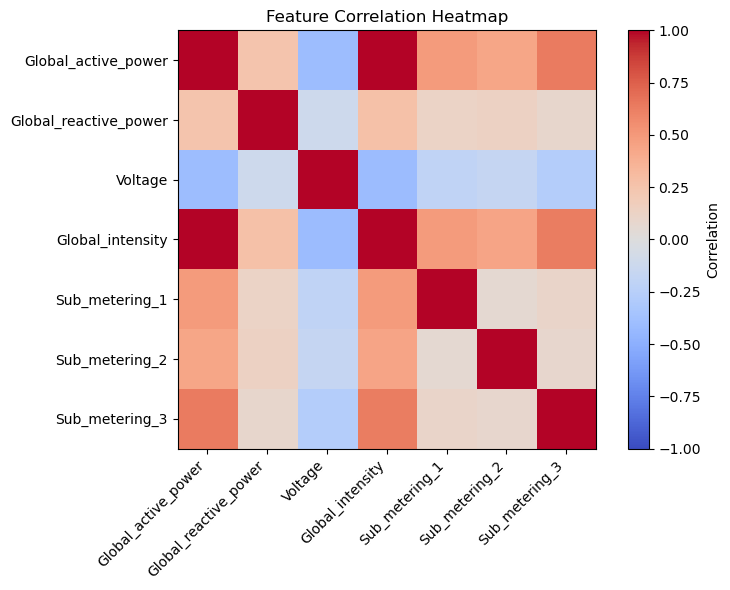

In [15]:
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right')
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 7. 按作业要求进行天级汇总

作业提示中要求：

- `Global_active_power`、`Global_reactive_power`、`Sub_metering_1`、`Sub_metering_2` 按天取总和
- `Voltage`、`Global_intensity` 按天取平均
- `Sub_metering_3` 是分表能耗，实际建模时通常也按天取总和
- 目标变量是接下来每一天的总有功功率，即天级 `Global_active_power`

In [16]:
df_indexed = df.set_index('datetime')

daily_df = df_indexed.resample('D').agg({
    'Global_active_power': 'sum',
    'Global_reactive_power': 'sum',
    'Voltage': 'mean',
    'Global_intensity': 'mean',
    'Sub_metering_1': 'sum',
    'Sub_metering_2': 'sum',
    'Sub_metering_3': 'sum',
})

daily_df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16,1209.176,34.922,236.243763,13.082828,0.0,546.0,4926.0
2006-12-17,3390.460,226.006,240.087028,9.999028,2033.0,4187.0,13341.0
2006-12-18,2203.826,161.792,241.231694,6.421667,1063.0,2621.0,14018.0
2006-12-19,1666.194,150.942,241.999313,4.926389,839.0,7602.0,6197.0
2006-12-20,2225.748,160.998,242.308062,6.467361,0.0,2648.0,14063.0


In [17]:
print(f'天级数据行数: {len(daily_df):,}')
print(f'天级起始日期: {daily_df.index.min().date()}')
print(f'天级结束日期: {daily_df.index.max().date()}')

daily_df.describe().T

天级数据行数: 1,442
天级起始日期: 2006-12-16
天级结束日期: 2010-11-26


,count,mean,std,min,25%,50%,75%,max
Global_active_power,1442.0,1551.334856,617.297117,0.000000,1161.198500,1534.778000,1889.859500,4773.386000
Global_reactive_power,1442.0,175.815258,51.998109,0.000000,140.911500,170.290000,202.372500,417.834000
Voltage,1433.0,240.836421,2.045493,231.088229,240.094778,240.965688,241.878583,247.435007
Global_intensity,1433.0,4.629728,1.741352,0.808333,3.503333,4.556111,5.540556,14.028056
Sub_metering_1,1442.0,1594.407074,1587.840580,0.000000,555.500000,1109.000000,2196.750000,11178.000000
Sub_metering_2,1442.0,1845.375173,2089.590342,0.000000,424.250000,678.500000,2712.750000,12109.000000
Sub_metering_3,1442.0,9178.340499,3787.898093,0.000000,6604.250000,9251.000000,11708.500000,23743.000000


In [18]:
daily_missing_summary = pd.DataFrame({
    'missing_count': daily_df.isna().sum(),
    'missing_rate_%': (daily_df.isna().sum() / len(daily_df) * 100).round(4),
})
daily_missing_summary

,missing_count,missing_rate_%
Global_active_power,0,0.0000
Global_reactive_power,0,0.0000
Voltage,9,0.6241
Global_intensity,9,0.6241
Sub_metering_1,0,0.0000
Sub_metering_2,0,0.0000
Sub_metering_3,0,0.0000


## 8. 目标变量趋势图

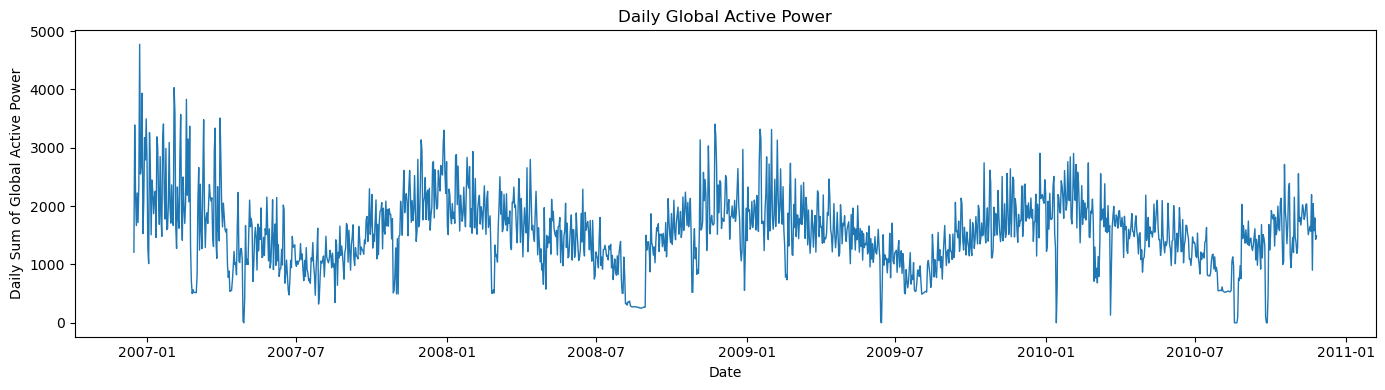

In [19]:
plt.figure(figsize=(14, 4))
plt.plot(daily_df.index, daily_df['Global_active_power'], linewidth=1)
plt.title('Daily Global Active Power')
plt.xlabel('Date')
plt.ylabel('Daily Sum of Global Active Power')
plt.tight_layout()
plt.show()

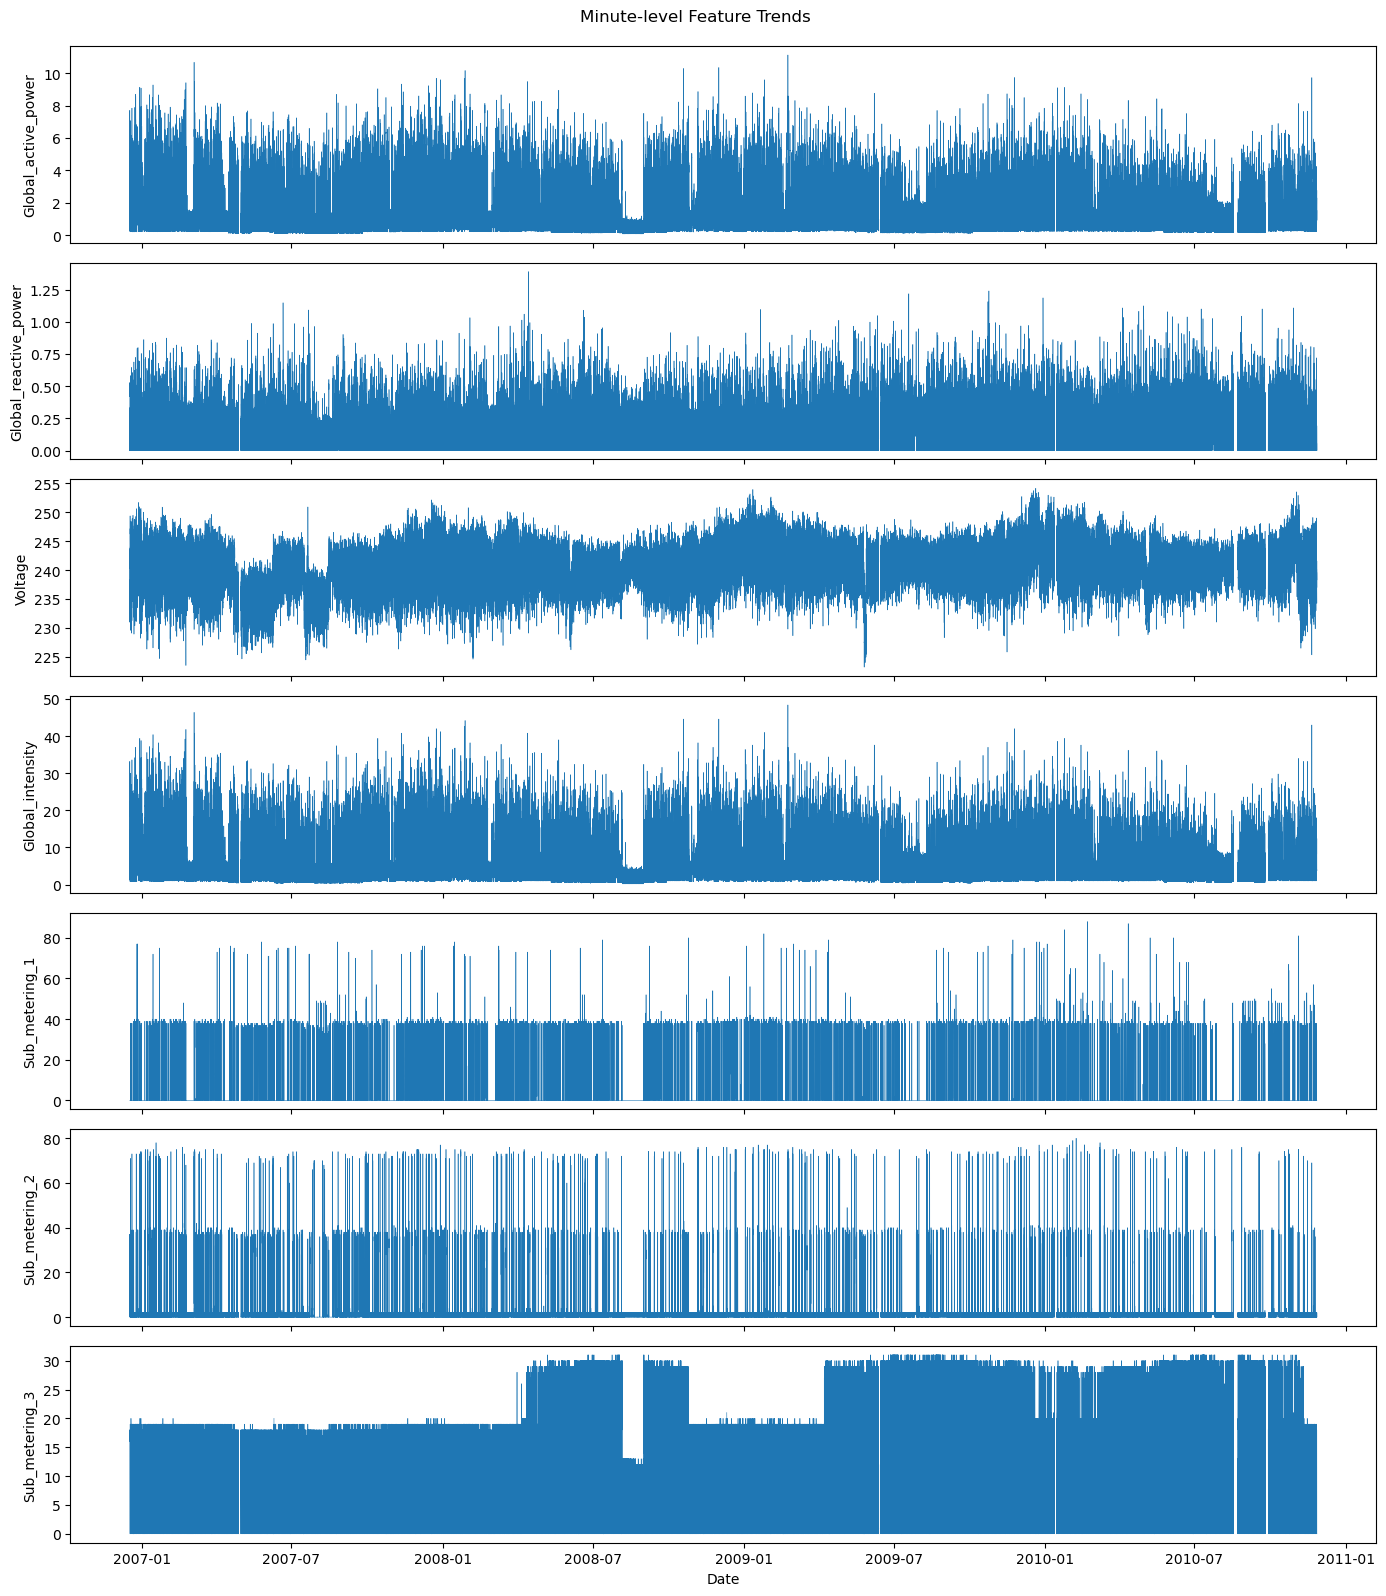

In [20]:
fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(14, 16), sharex=True)

for ax, col in zip(axes, numeric_cols):
    ax.plot(df['datetime'], df[col], linewidth=0.4)
    ax.set_ylabel(col)

axes[-1].set_xlabel('Date')
fig.suptitle('Minute-level Feature Trends', y=0.995)
plt.tight_layout()
plt.show()

## 9. 异常值初步查看

这里使用 IQR 方法粗略统计异常值数量，目的是发现可能偏离正常范围较大的观测点。异常值不一定要删除，后续建模时需要结合任务和数据背景判断。

In [21]:
outlier_rows = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append({
        'column': col,
        'lower_bound': lower,
        'upper_bound': upper,
        'outlier_count': int(count),
        'outlier_rate_%': round(count / len(df) * 100, 4),
    })

outlier_summary = pd.DataFrame(outlier_rows)
outlier_summary

,column,lower_bound,upper_bound,outlier_count,outlier_rate_%
0,Global_active_power,-1.522,3.358,94907,4.5733
1,Global_reactive_power,-0.171,0.413,40420,1.9477
2,Voltage,233.140,248.740,51067,2.4608
3,Global_intensity,-6.100,13.900,100961,4.8650
4,Sub_metering_1,0.000,0.000,169105,8.1486
5,Sub_metering_2,-1.500,2.500,77151,3.7177
6,Sub_metering_3,-25.500,42.500,0,0.0000


## 10. 初步结论记录

运行完上面的单元格后，可以在这里补充观察结论，例如：

1. 数据时间跨度是否完整。
2. 哪些字段存在缺失值，缺失比例是多少。
3. 目标变量 `Global_active_power` 的最大值、最小值、均值和趋势特点。
4. 是否存在明显异常值或记录不完整的日期。
5. 后续建模前是否需要插值、标准化、滑动窗口切分。